# Projet AI & Optimization 2025 / 2026
## Classification de cellules sur images histologiques

**Membres de l'equipe :**
- Camille Chaptini
- *(Nom 2)*
- *(Nom 3)*

---

### Objectif

Le presents notebook propose une methode de classification automatique
de patchs d'images histologiques colorees en hematoxyline-eosine (H&E)
en quatre categories : *Lymphocyte*, *Tumor*, *Plasma* et *Fibroblast*.

### Plan

Le notebook suit le plan defini dans les consignes :

1. Exploration des donnees.
2. Extraction de caracteristiques implementees a la main.
3. Entrainement de modeles de classification.
4. Prediction sur le futur jeu de test.

L'integralite des methodes mobilisees provient des cours magistraux
**CM 08, CM 09 et CM 10**. Le tableau ci-dessous etablit la
correspondance entre chaque element du pipeline et sa source.

| Element                          | Source                                  |
| -------------------------------- | --------------------------------------- |
| `StandardScaler`                 | CM 10, diapositive 20                   |
| `StratifiedKFold` (5 plis)       | CM 09, diapositives 13-14                |
| `SelectKBest` avec `f_classif`   | CM 09, diapositives 19 et 24-25          |
| `GridSearchCV`                   | CM 09, diapositive 40                    |
| `RandomizedSearchCV`             | CM 09, diapositives 41-42                |
| `LogisticRegression`             | CM 08 (presentation generale)            |
| Solveur L-BFGS                   | CM 10, diapositives 6-11                 |
| Support Vector Machine lineaire  | CM 09 (illustrations)                    |
| `SGDClassifier`                  | CM 10, diapositives 15-22                |


## 0. Imports et chemins

L'ensemble des bibliotheques mobilisees correspond a celles employees
dans les cours magistraux et les travaux pratiques.


In [1]:
# Imports systeme
import os
import warnings
warnings.filterwarnings("ignore")

# Calcul scientifique
import numpy as np
import pandas as pd
from PIL import Image
import scipy.ndimage as ndi  # introduit en Lab 01

# Visualisation
import matplotlib.pyplot as plt

# Apprentissage automatique : outils issus des CM 08, 09 et 10
from sklearn.model_selection import (
    StratifiedKFold,        # CM 09 diapositive 13
    cross_val_score,
    GridSearchCV,           # CM 09 diapositive 40
    RandomizedSearchCV,     # CM 09 diapositive 41
    cross_val_predict,
)
from sklearn.preprocessing import StandardScaler        # CM 10 diapo 20
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    SelectKBest, f_classif,                              # CM 09 diapo 19
)
from sklearn.linear_model import (
    LogisticRegression,     # CM 08 + CM 10 (L-BFGS, diapo 11)
    SGDClassifier,          # CM 10 diapos 15-22
)
from sklearn.svm import SVC                              # CM 09
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score
)
from scipy.stats import loguniform     # support pour RandomizedSearchCV

# Reproductibilite
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Chemins (notebook situe a la racine du projet)
DATA_DIR     = "."
IMG_DIR      = os.path.join(DATA_DIR, "DATASET_images")
TRAIN_CSV    = os.path.join(DATA_DIR, "train.csv")
FEATURES_CSV = os.path.join(DATA_DIR, "features_train.csv")

print("Dossier des images :", IMG_DIR)
print("Fichier d'entrainement :", TRAIN_CSV)

Dossier des images : ./DATASET_images
Fichier d'entrainement : ./train.csv


## 1. Exploration des donnees

### a) Chargement et statistiques descriptives


In [2]:
# La colonne Image est lue en chaine de caracteres afin de
# preserver les zeros initiaux des identifiants ("00", "01", ...).
train_df = pd.read_csv(TRAIN_CSV, dtype={"Image": str})
print(f"Nombre total d'echantillons : {len(train_df)}")
print(f"Colonnes presentes : {list(train_df.columns)}")
train_df.head()

Nombre total d'echantillons : 400
Colonnes presentes : ['Image', 'Label']


,Image,Label
0,00,Lymphocyte
1,01,Tumor
2,02,Tumor
3,03,Lymphocyte
4,04,Plasma


In [3]:
counts = train_df["Label"].value_counts()
print("Distribution des labels :")
print(counts)
print()
print("Proportions :")
print((counts / counts.sum()).round(3))

Distribution des labels :
Label
Lymphocyte    100
Tumor         100
Plasma        100
Fibroblast    100
Name: count, dtype: int64

Proportions :
Label
Lymphocyte    0.25
Tumor         0.25
Plasma        0.25
Fibroblast    0.25
Name: count, dtype: float64


Le jeu de donnees est equilibre : il comporte exactement 100
echantillons par classe pour un total de 400 patchs. Aucune
ponderation de classe n'est donc necessaire lors de l'entrainement.


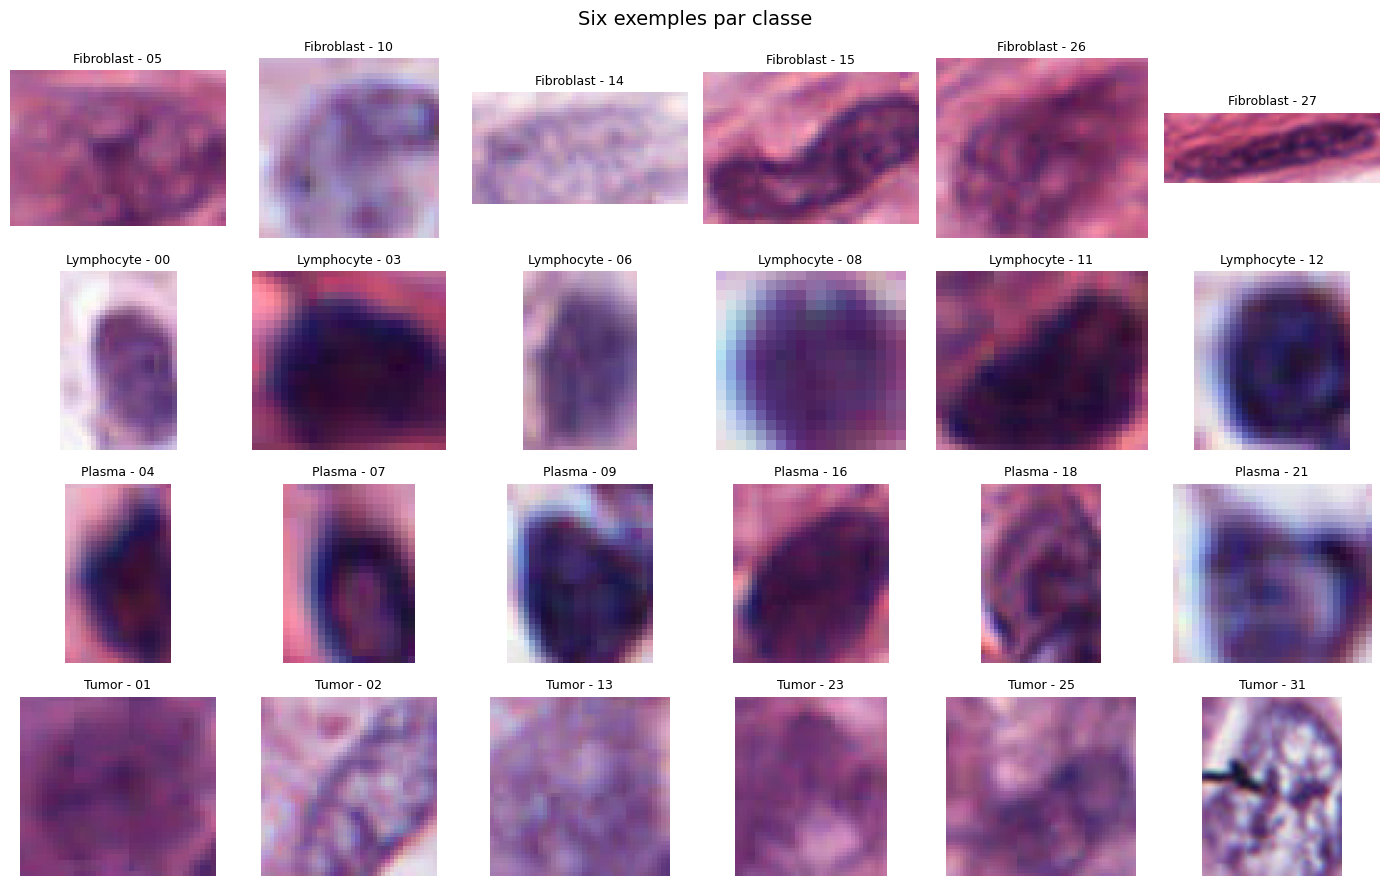

In [4]:
# Echantillon de six images par classe a titre illustratif
fig, axes = plt.subplots(4, 6, figsize=(14, 9))
for ci, (cls, sub) in enumerate(train_df.groupby("Label")):
    sample_ids = sub["Image"].head(6).tolist()
    for j, im_id in enumerate(sample_ids):
        img = np.array(Image.open(
            os.path.join(IMG_DIR, im_id + ".png")
        ))
        axes[ci, j].imshow(img)
        axes[ci, j].set_title(f"{cls} - {im_id}", fontsize=9)
        axes[ci, j].axis("off")
plt.suptitle("Six exemples par classe", fontsize=14)
plt.tight_layout()
plt.show()

### b) Distribution des tailles de patchs

Les patchs n'ont pas tous les memes dimensions, leur taille reflete
la dimension de la cellule decoupee. Nous evaluons l'apport
informatif de cette caracteristique.


In [5]:
records = []
for _, row in train_df.iterrows():
    img = np.array(Image.open(
        os.path.join(IMG_DIR, row["Image"] + ".png")
    ))
    h, w = img.shape[:2]
    records.append({"Label": row["Label"], "h": h, "w": w,
                    "area": h * w})
size_df = pd.DataFrame(records)
print(size_df.groupby("Label")[["h", "w", "area"]].mean().round(1))

               h     w    area
Label                         
Fibroblast  43.5  48.9  2100.7
Lymphocyte  26.5  26.4   716.5
Plasma      27.6  28.0   780.9
Tumor       43.6  47.2  2111.8


Les statistiques descriptives confirment plusieurs proprietes
attendues du point de vue histologique :

- les *Lymphocytes* sont de petite taille (environ 25 pixels de cote)
  et presentent un noyau dense ;
- les *Plasmocytes* possedent des dimensions comparables, mais leur
  cytoplasme rose forme une couronne distinctive autour du noyau ;
- les *Tumor* sont de plus grande taille (environ 45 pixels) et
  presentent une forme globalement arrondie ;
- les *Fibroblastes* sont allonges, leur largeur est sensiblement
  superieure a leur hauteur.

La principale source de confusion attendue concerne la distinction
entre Lymphocyte et Plasma, leurs noyaux etant visuellement proches.


## 2. Extraction des caracteristiques

Conformement aux consignes, l'ensemble des descripteurs est code a la
main en pur `numpy` et `scipy.ndimage`. Aucune bibliotheque d'analyse
d'image specialisee n'est utilisee. Trois familles de descripteurs
sont extraites : forme et aire, intensite, texture.


### a) Conversion RGB vers HSV

L'espace colorimetrique HSV est plus adapte que le RGB pour
discriminer les teintes violettes (noyau) des teintes roses
(cytoplasme).


In [6]:
def rgb_to_hsv(rgb):
    # Conversion canal par canal. Chaque composante est dans [0, 1].
    img = rgb.astype(np.float32) / 255.0
    R, G, B = img[..., 0], img[..., 1], img[..., 2]
    maxc = np.maximum(np.maximum(R, G), B)
    minc = np.minimum(np.minimum(R, G), B)
    V = maxc
    delta = maxc - minc
    S = np.where(maxc > 1e-6, delta / (maxc + 1e-9), 0.0)
    H = np.zeros_like(R)
    msk = delta > 1e-6
    rc = np.where(msk, (maxc - R) / (delta + 1e-9), 0.0)
    gc = np.where(msk, (maxc - G) / (delta + 1e-9), 0.0)
    bc = np.where(msk, (maxc - B) / (delta + 1e-9), 0.0)
    H = np.where(R == maxc, bc - gc, H)
    H = np.where(G == maxc, 2.0 + rc - bc, H)
    H = np.where(B == maxc, 4.0 + gc - rc, H)
    H = (H / 6.0) % 1.0
    H[~msk] = 0.0
    return H, S, V

### b) Segmentation du noyau par seuillage d'Otsu

Sur une image colorisee en H&E, le noyau cellulaire est riche en
hematoxyline et apparait nettement sombre sur le canal vert. Le
canal `B - G` constitue une approximation efficace de la
concentration en hematoxyline. Le seuil optimal est determine par
la methode d'Otsu, qui maximise la variance inter-classes du
foreground et du background. Le masque obtenu est ensuite nettoye
par remplissage des trous (technique introduite en Lab 01), puis
restreint a la composante connexe contenant le centre du patch.


In [7]:
def otsu_threshold(arr):
    # Determine le seuil d'Otsu maximisant la variance inter-classe.
    flat = arr.ravel()
    hist, edges = np.histogram(flat, bins=64,
                                range=(flat.min(), flat.max()))
    hist = hist.astype(np.float64)
    total = hist.sum()
    if total == 0:
        return 0.0
    p = hist / total
    cum_p = np.cumsum(p)
    mids = (edges[:-1] + edges[1:]) / 2.0
    cum_m = np.cumsum(p * mids)
    mu_t = cum_m[-1]
    sigma2_b = ((mu_t * cum_p - cum_m) ** 2
                / (cum_p * (1 - cum_p) + 1e-12))
    return float(mids[int(np.argmax(sigma2_b))])


def segment_nucleus(img_rgb):
    img = img_rgb.astype(np.float32) / 255.0
    nuclear = img[..., 2] - img[..., 1]  # canal B - G
    thr = otsu_threshold(nuclear)
    mask = (nuclear >= thr).astype(np.uint8)
    mask = ndi.binary_fill_holes(mask).astype(np.uint8)
    if mask.sum() < 5:
        # Procedure de repli si Otsu echoue
        g = img_rgb[:, :, 1].astype(np.float32)
        mask = (g <= g.mean() - 0.3 * g.std()).astype(np.uint8)
        mask = ndi.binary_fill_holes(mask).astype(np.uint8)
    ccs, n = ndi.label(mask)
    if n == 0:
        return mask
    h, w = mask.shape
    central = ccs[h // 2, w // 2]
    if central > 0:
        chosen = central
    else:
        ids, counts = np.unique(ccs[ccs > 0], return_counts=True)
        chosen = ids[np.argmax(counts)]
    return (ccs == chosen).astype(np.uint8)

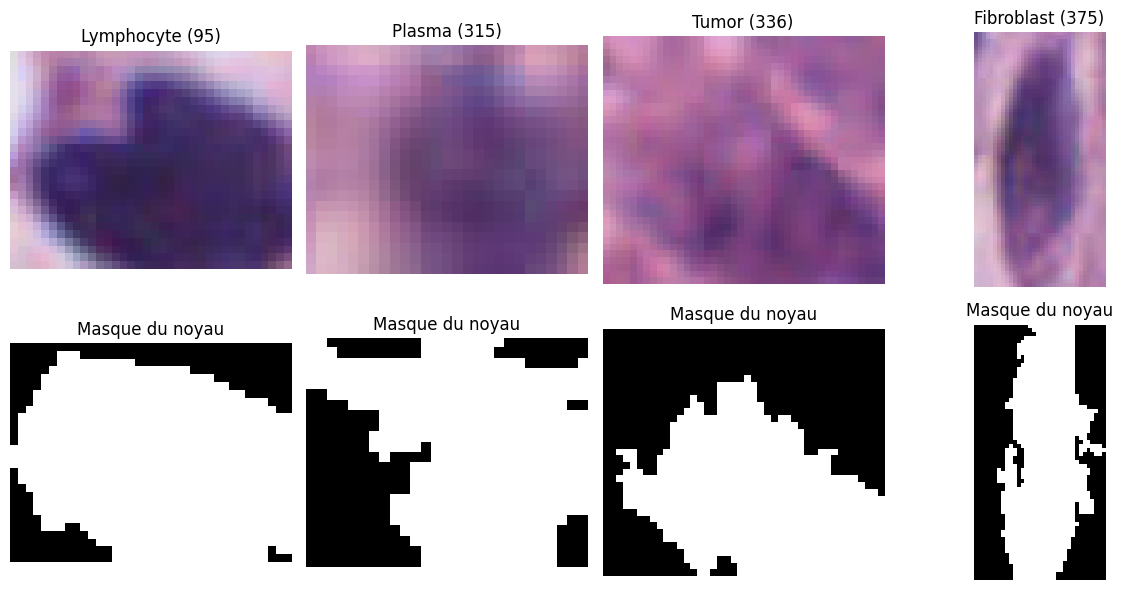

In [8]:
# Verification visuelle de la qualite de la segmentation
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for k, cls in enumerate(["Lymphocyte", "Plasma", "Tumor", "Fibroblast"]):
    im_id = train_df[train_df["Label"] == cls].sample(
        1, random_state=k).iloc[0]["Image"]
    img = np.array(Image.open(os.path.join(IMG_DIR, im_id + ".png")))
    mask = segment_nucleus(img)
    ax[0, k].imshow(img); ax[0, k].set_title(f"{cls} ({im_id})")
    ax[0, k].axis("off")
    ax[1, k].imshow(mask, cmap="gray"); ax[1, k].set_title("Masque du noyau")
    ax[1, k].axis("off")
plt.tight_layout(); plt.show()

### c) Descripteurs de forme et d'aire

A partir du masque binaire, les descripteurs suivants sont
calcules : aire, perimetre (par soustraction du masque et de son
erosion), circularite, dimensions de la boite englobante,
allongement et excentricite. L'excentricite est obtenue par
diagonalisation de la matrice de covariance des coordonnees des
pixels du masque (analyse en composantes principales).


In [9]:
def shape_features(mask):
    feats = {}
    area = float(mask.sum())
    feats["area"]       = area
    feats["area_ratio"] = area / (mask.size + 1e-9)
    if area < 3:
        feats.update({
            "perimeter": 0.0, "circularity": 0.0,
            "bbox_h": 0.0, "bbox_w": 0.0, "bbox_fill": 0.0,
            "elongation": 1.0, "eccentricity": 0.0,
        })
        return feats
    eroded = ndi.binary_erosion(mask).astype(np.uint8)
    perimeter = float((mask - eroded).sum())
    feats["perimeter"]   = perimeter
    feats["circularity"] = float(
        4.0 * np.pi * area / (perimeter ** 2 + 1e-9))
    xs, ys = np.where(mask)
    bbox_h = xs.max() - xs.min() + 1
    bbox_w = ys.max() - ys.min() + 1
    feats["bbox_h"]    = float(bbox_h)
    feats["bbox_w"]    = float(bbox_w)
    feats["bbox_fill"] = float(area / (bbox_h * bbox_w + 1e-9))
    feats["elongation"] = float(
        max(bbox_h, bbox_w) / (min(bbox_h, bbox_w) + 1e-9))
    # Excentricite par diagonalisation de la matrice de covariance
    dx = xs - xs.mean(); dy = ys - ys.mean()
    cov = np.array([
        [(dx * dx).mean(), (dx * dy).mean()],
        [(dx * dy).mean(), (dy * dy).mean()],
    ])
    eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]
    if eigvals[0] > 1e-9:
        feats["eccentricity"] = float(
            np.sqrt(1.0 - eigvals[1] / (eigvals[0] + 1e-9)))
    else:
        feats["eccentricity"] = 0.0
    return feats

### d) Descripteurs d'intensite

Pour chaque canal pertinent (R, G, B, niveaux de gris, B - G assimile
a l'hematoxyline, R - B assimile a l'eosine, H, S, V) sont calcules
la moyenne, l'ecart-type, les valeurs extremes et les percentiles
25, 50 et 75. Ces statistiques sont evaluees sur l'integralite du
patch ainsi que sur la region du noyau segmente.


In [10]:
def channel_stats(ch, prefix):
    f = {}
    f[f"{prefix}_mean"] = float(ch.mean())
    f[f"{prefix}_std"]  = float(ch.std())
    f[f"{prefix}_min"]  = float(ch.min())
    f[f"{prefix}_max"]  = float(ch.max())
    f[f"{prefix}_p25"]  = float(np.percentile(ch, 25))
    f[f"{prefix}_p50"]  = float(np.percentile(ch, 50))
    f[f"{prefix}_p75"]  = float(np.percentile(ch, 75))
    return f


def intensity_features(img_rgb, mask):
    f = {}
    img = img_rgb.astype(np.float32) / 255.0
    R, G, B = img[..., 0], img[..., 1], img[..., 2]
    gray  = 0.299 * R + 0.587 * G + 0.114 * B
    hema  = B - G      # approximation de l'hematoxyline
    eosin = R - B      # approximation de l'eosine
    H, S, V = rgb_to_hsv(img_rgb)
    channels = {"R":R, "G":G, "B":B, "gray":gray,
                "Hema":hema, "Eosin":eosin,
                "H":H, "S":S, "V":V}
    # Statistiques sur le patch global
    for name, ch in channels.items():
        f.update(channel_stats(ch, f"all_{name}"))
    # Statistiques restreintes au noyau
    nuc = mask == 1
    if nuc.sum() >= 3:
        for name, ch in channels.items():
            f.update(channel_stats(ch[nuc], f"nuc_{name}"))
    else:
        for name in channels:
            for s in ["mean","std","min","max","p25","p50","p75"]:
                f[f"nuc_{name}_{s}"] = f[f"all_{name}_{s}"]
    return f

### e) Descripteurs de texture

Deux mesures simples de texture sont retenues : l'energie du gradient
calculee par filtres de Sobel et la variance du Laplacien. Ces
quantites refletent l'intensite des contours et la nettete locale
du patch.


In [11]:
def texture_features(img_rgb):
    g  = img_rgb[:, :, 1].astype(np.float32) / 255.0
    gx = ndi.sobel(g, axis=0)
    gy = ndi.sobel(g, axis=1)
    grad = np.sqrt(gx ** 2 + gy ** 2)
    lap  = ndi.laplace(g)
    return {
        "edge_mean":   float(grad.mean()),
        "edge_std":    float(grad.std()),
        "laplace_var": float(lap.var()),
    }

### f) Constitution du tableau de caracteristiques

L'ensemble des descripteurs est calcule sur les 400 patchs
d'entrainement, puis sauvegarde dans un fichier CSV conformement
aux recommandations des consignes.


In [12]:
def extract_features(img_rgb):
    feats = {}
    h, w = img_rgb.shape[:2]
    feats["patch_h"]      = float(h)
    feats["patch_w"]      = float(w)
    feats["patch_area"]   = float(h * w)
    feats["patch_aspect"] = float(max(h, w) / (min(h, w) + 1e-9))
    mask = segment_nucleus(img_rgb)
    feats.update(shape_features(mask))
    feats.update(intensity_features(img_rgb, mask))
    feats.update(texture_features(img_rgb))
    return feats


def build_features_dataframe(image_ids, img_dir, labels=None):
    rows = []
    for k, im_id in enumerate(image_ids):
        img = np.array(Image.open(
            os.path.join(img_dir, im_id + ".png")))
        f = extract_features(img)
        f["Image"] = im_id
        if labels is not None:
            f["Label"] = labels[k]
        rows.append(f)
    df = pd.DataFrame(rows)
    cols = ["Image"]
    if labels is not None:
        cols.append("Label")
    cols += [c for c in df.columns if c not in cols]
    return df[cols]


print("Extraction des caracteristiques sur les 400 patchs...")
features_df = build_features_dataframe(
    train_df["Image"].tolist(), IMG_DIR,
    labels=train_df["Label"].tolist(),
)
features_df.to_csv(FEATURES_CSV, index=False)
print(f"Nombre de caracteristiques extraites : "
      f"{features_df.shape[1] - 2}")
features_df.head()

Extraction des caracteristiques sur les 400 patchs...


Nombre de caracteristiques extraites : 142


,Image,Label,patch_h,patch_w,patch_area,patch_aspect,area,area_ratio,perimeter,circularity,...,nuc_V_mean,nuc_V_std,nuc_V_min,nuc_V_max,nuc_V_p25,nuc_V_p50,nuc_V_p75,edge_mean,edge_std,laplace_var
0,00,Lymphocyte,40.0,26.0,1040.0,1.538462,535.0,0.514423,102.0,0.646195,...,0.569786,0.109592,0.415686,0.901961,0.490196,0.525490,0.635294,0.373443,0.322162,0.002770
1,01,Tumor,33.0,36.0,1188.0,1.090909,911.0,0.766835,173.0,0.382504,...,0.451415,0.063534,0.317647,0.694118,0.411765,0.439216,0.486275,0.124914,0.082272,0.000597
2,02,Tumor,42.0,41.0,1722.0,1.024390,1085.0,0.630081,154.0,0.574908,...,0.655245,0.074767,0.466667,0.901961,0.603922,0.654902,0.709804,0.359658,0.224529,0.002947
3,03,Lymphocyte,25.0,27.0,675.0,1.080000,308.0,0.456296,140.0,0.197472,...,0.377400,0.125451,0.192157,0.811765,0.282353,0.341176,0.436275,0.230363,0.181308,0.001118
4,04,Plasma,34.0,20.0,680.0,1.700000,478.0,0.702941,93.0,0.694499,...,0.363024,0.123751,0.200000,0.717647,0.274510,0.313726,0.430392,0.282432,0.200497,0.001146


### g) Analyse statistique des caracteristiques

Le test ANOVA F-value permet de classer les caracteristiques selon
leur pouvoir discriminant individuel. Cette analyse univariee est
celle preconisee dans le **CM 09, diapositive 25**, et constitue le
critere utilise par `SelectKBest` dans la suite du pipeline.


In [13]:
y = features_df["Label"].values
X = features_df.drop(columns=["Image", "Label"]).values
feature_names = features_df.drop(
    columns=["Image", "Label"]
).columns.tolist()

X_scaled = StandardScaler().fit_transform(X)
F_vals, _ = f_classif(X_scaled, y)
order = sorted(zip(feature_names, F_vals), key=lambda r: -r[1])
print("Dix caracteristiques les plus discriminantes (ANOVA F-value) :")
for name, fv in order[:10]:
    print(f"  {name:25s}  F = {fv:7.2f}")

Dix caracteristiques les plus discriminantes (ANOVA F-value) :
  all_R_p25                  F =  153.54
  nuc_R_p50                  F =  147.77
  nuc_R_mean                 F =  131.86
  nuc_R_p25                  F =  129.34
  all_R_p50                  F =  121.90
  nuc_R_p75                  F =  104.14
  patch_area                 F =   95.69
  all_R_mean                 F =   92.14
  patch_w                    F =   91.42
  all_Eosin_p50              F =   88.25


## 3. Entrainement des modeles de classification

### a) Strategie d'optimisation

Le pipeline d'apprentissage s'appuie exclusivement sur les briques
methodologiques presentees dans les cours magistraux. Le tableau
suivant explicite cette correspondance.

| Etape                          | Outil                       | Source            |
| ------------------------------ | --------------------------- | ----------------- |
| Validation croisee             | `StratifiedKFold(5)`        | CM 09, diapo 13   |
| Normalisation                  | `StandardScaler`            | CM 10, diapo 20   |
| Selection de caracteristiques  | `SelectKBest(f_classif)`    | CM 09, diapo 19-25|
| Tuning par grille              | `GridSearchCV`              | CM 09, diapo 40   |
| Tuning par echantillonnage     | `RandomizedSearchCV`        | CM 09, diapo 41-42|

Trois algorithmes de classification sont compares, choisis pour leur
presence explicite dans les cours :

1. **Regression logistique** entrainee par le solveur **L-BFGS**
   (CM 08 pour la presentation generale, CM 10 diapositives 6-11
   pour l'algorithme d'optimisation).
2. **Machine a vecteurs de support** a noyau lineaire, conformement
   aux illustrations du CM 09.
3. **Stochastic Gradient Descent** (CM 10, diapositives 15-22) avec
   la perte `log_loss`, ce qui correspond a une regression logistique
   entrainee par SGD plutot que par L-BFGS.


In [14]:
# Validation croisee stratifiee a 5 plis (CM 09 diapo 13)
cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)
print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


### b) Modele 1 : Regression logistique avec solveur L-BFGS

Le CM 10 detaille la methode L-BFGS comme une approximation a
memoire limitee de l'algorithme BFGS. Elle constitue le solveur par
defaut pour la regression logistique dans scikit-learn et est
particulierement adaptee aux problemes de taille moderee. La
diapositive 11 du CM 10 presente une experience analogue
(LogReg + L-BFGS + normalisation + GridSearchCV sur le parametre
`C`).

Le tuning est realise par `GridSearchCV` (CM 09, diapositive 40)
sur le parametre de regularisation `C` et le nombre de
caracteristiques selectionnees `k`.


In [15]:
lr_pipe = Pipeline([
    ("sc",  StandardScaler()),                  # CM 10 diapo 20
    ("sel", SelectKBest(f_classif)),            # CM 09 diapo 19
    ("clf", LogisticRegression(
        solver="lbfgs",                          # CM 10 diapo 11
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])
lr_grid = {
    "sel__k": [40, 80, 120],
    "clf__C": [0.3, 1.0, 3.0],
}
lr_gs = GridSearchCV(
    lr_pipe, lr_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
lr_gs.fit(X, y)
print(f"Regression logistique (L-BFGS) : "
      f"accuracy = {lr_gs.best_score_:.4f}")
print(f"Hyperparametres : {lr_gs.best_params_}")

Regression logistique (L-BFGS) : accuracy = 0.7400
Hyperparametres : {'clf__C': 0.3, 'sel__k': 80}


### c) Modele 2 : Support Vector Machine lineaire

Le CM 09 mobilise systematiquement les SVM a noyau lineaire dans
ses illustrations relatives a la selection de caracteristiques
(RFE, SFS, comparaisons univariees). Cette configuration constitue
la reference utilisee dans ce travail.


In [16]:
svm_pipe = Pipeline([
    ("sc",  StandardScaler()),
    ("sel", SelectKBest(f_classif)),
    ("clf", SVC(kernel="linear", random_state=RANDOM_STATE)),
])
svm_grid = {
    "sel__k": [40, 80, 120],
    "clf__C": [0.1, 1.0, 10.0],
}
svm_gs = GridSearchCV(
    svm_pipe, svm_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
svm_gs.fit(X, y)
print(f"SVM lineaire : accuracy = {svm_gs.best_score_:.4f}")
print(f"Hyperparametres : {svm_gs.best_params_}")

SVM lineaire : accuracy = 0.7450
Hyperparametres : {'clf__C': 0.1, 'sel__k': 80}


### d) Modele 3 : Stochastic Gradient Descent

Le CM 10, dans ses diapositives 15 a 22, presente l'algorithme SGD
comme une adaptation du gradient descendant pour les problemes de
grande dimension. A chaque iteration, les poids sont mis a jour a
partir du gradient evalue sur un seul echantillon ou un mini-lot,
au lieu de l'ensemble du jeu d'entrainement.

Le choix de la perte `log_loss` rend le `SGDClassifier`
mathematiquement equivalent a la regression logistique. La
comparaison directe avec le modele precedent permet ainsi
d'evaluer l'effet du seul algorithme d'optimisation.

Les hyperparametres `alpha` et `eta0` etant continus, le tuning
est realise par `RandomizedSearchCV` (CM 09, diapositives 41-42),
qui explore plus efficacement l'espace de recherche qu'une grille
discrete.


In [17]:
sgd_pipe = Pipeline([
    ("sc",  StandardScaler()),              # CM 10 diapo 20
    ("sel", SelectKBest(f_classif)),
    ("clf", SGDClassifier(
        loss="log_loss",
        max_iter=2000, tol=1e-4,
        random_state=RANDOM_STATE,
    )),
])
sgd_dist = {
    "sel__k":              [40, 80, 120],
    "clf__alpha":          loguniform(1e-5, 1e-1),
    "clf__eta0":           loguniform(1e-4, 1e-1),
    "clf__learning_rate":  ["optimal", "constant", "adaptive"],
}
sgd_rs = RandomizedSearchCV(
    sgd_pipe, sgd_dist, n_iter=20, cv=cv,
    scoring="accuracy", n_jobs=-1, random_state=RANDOM_STATE
)
sgd_rs.fit(X, y)
print(f"SGD : accuracy = {sgd_rs.best_score_:.4f}")
print(f"Hyperparametres : {sgd_rs.best_params_}")

SGD : accuracy = 0.7350
Hyperparametres : {'clf__alpha': np.float64(0.0006870614282613297), 'clf__eta0': np.float64(0.0010025956902289571), 'clf__learning_rate': 'adaptive', 'sel__k': 80}


### e) Comparaison entre GridSearchCV et RandomizedSearchCV

Le CM 09 (diapositives 41-42) etablit que la recherche aleatoire
atteint des performances comparables a la grille pour un cout
calcul reduit, en explorant un espace continu plutot qu'une grille
discrete. Cette comparaison est reproduite ci-dessous sur le
modele SVM lineaire.


In [18]:
svm_dist = {
    "sel__k":  [40, 80, 120],
    "clf__C":  loguniform(0.05, 30.0),
}
svm_rs = RandomizedSearchCV(
    svm_pipe, svm_dist, n_iter=15, cv=cv,
    scoring="accuracy", n_jobs=-1, random_state=RANDOM_STATE
)
svm_rs.fit(X, y)
print(f"SVM via GridSearchCV       : {svm_gs.best_score_:.4f}")
print(f"SVM via RandomizedSearchCV : {svm_rs.best_score_:.4f}")

SVM via GridSearchCV       : 0.7450
SVM via RandomizedSearchCV : 0.7275


### f) Synthese des resultats et selection du modele final


In [19]:
summary = pd.DataFrame([
    {"modele": "Regression logistique (L-BFGS)",
     "acc_cv": lr_gs.best_score_,
     "params": str(lr_gs.best_params_)},
    {"modele": "SVM lineaire (GridSearchCV)",
     "acc_cv": svm_gs.best_score_,
     "params": str(svm_gs.best_params_)},
    {"modele": "SVM lineaire (RandomizedSearchCV)",
     "acc_cv": svm_rs.best_score_,
     "params": str(svm_rs.best_params_)},
    {"modele": "SGD (log_loss)",
     "acc_cv": sgd_rs.best_score_,
     "params": str(sgd_rs.best_params_)},
]).sort_values("acc_cv", ascending=False).reset_index(drop=True)
summary

,modele,acc_cv,params
0,SVM lineaire (GridSearchCV),0.7450,"{'clf__C': 0.1, 'sel__k': 80}"
1,Regression logistique (L-BFGS),0.7400,"{'clf__C': 0.3, 'sel__k': 80}"
2,SGD (log_loss),0.7350,{'clf__alpha': np.float64(0.000687061428261329...
3,SVM lineaire (RandomizedSearchCV),0.7275,"{'clf__C': np.float64(0.13562706888337656), 's..."


In [20]:
# Selection du modele presentant la meilleure accuracy en
# cross-validation
candidates = {
    "Regression logistique (L-BFGS)": lr_gs,
    "SVM lineaire (grille)":          svm_gs,
    "SVM lineaire (aleatoire)":       svm_rs,
    "SGD":                            sgd_rs,
}
best_name  = max(candidates, key=lambda k: candidates[k].best_score_)
best_gs    = candidates[best_name]
best_model = best_gs.best_estimator_
print(f"Modele retenu  : {best_name}")
print(f"Accuracy CV    : {best_gs.best_score_:.4f}")
print(f"Hyperparametres : {best_gs.best_params_}")

Modele retenu  : SVM lineaire (grille)
Accuracy CV    : 0.7450
Hyperparametres : {'clf__C': 0.1, 'sel__k': 80}


### g) Analyse des erreurs

La matrice de confusion, calculee en validation croisee, permet
d'identifier les classes les plus confondues.


In [21]:
y_pred = cross_val_predict(best_model, X, y, cv=cv, n_jobs=-1)
labels_sorted = sorted(np.unique(y))
cm = confusion_matrix(y, y_pred, labels=labels_sorted)
cm_df = pd.DataFrame(cm, index=labels_sorted, columns=labels_sorted)
print("Matrice de confusion (validation croisee) :")
print(cm_df)
print()
print(classification_report(y, y_pred, labels=labels_sorted))

Matrice de confusion (validation croisee) :
            Fibroblast  Lymphocyte  Plasma  Tumor
Fibroblast          86           2       2     10
Lymphocyte           3          67      30      0
Plasma               2          29      65      4
Tumor               11           1       8     80

              precision    recall  f1-score   support

  Fibroblast       0.84      0.86      0.85       100
  Lymphocyte       0.68      0.67      0.67       100
      Plasma       0.62      0.65      0.63       100
       Tumor       0.85      0.80      0.82       100

    accuracy                           0.74       400
   macro avg       0.75      0.75      0.75       400
weighted avg       0.75      0.74      0.75       400



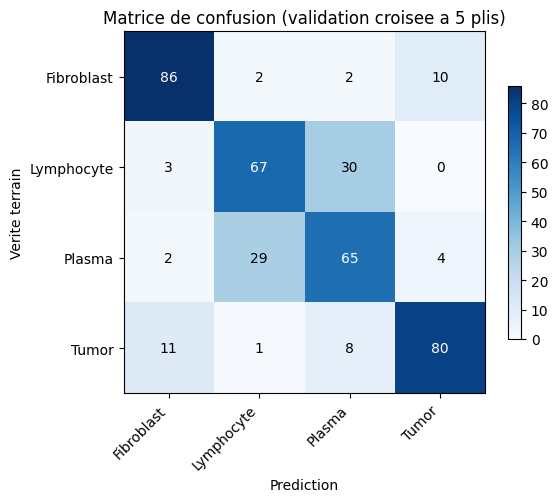

In [22]:
# Representation graphique de la matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted, rotation=45, ha="right")
ax.set_yticks(range(len(labels_sorted)))
ax.set_yticklabels(labels_sorted)
ax.set_xlabel("Prediction"); ax.set_ylabel("Verite terrain")
ax.set_title("Matrice de confusion (validation croisee a 5 plis)")
for i in range(len(labels_sorted)):
    for j in range(len(labels_sorted)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

Les erreurs de classification se concentrent sur les classes
*Lymphocyte* et *Plasma*, conformement aux observations issues de
l'exploration visuelle des donnees. La distinction entre ces deux
types cellulaires repose principalement sur la presence d'une
couronne cytoplasmique chez les plasmocytes, information non
toujours capturee par les caracteristiques retenues.


### h) Reentrainement du modele final

`GridSearchCV` et `RandomizedSearchCV` reentrainent par defaut
le meilleur modele sur l'integralite du jeu d'entrainement
(`refit=True`).


In [23]:
final_model = best_model
in_acc = accuracy_score(y, final_model.predict(X))
print(f"Accuracy en in-sample            : {in_acc:.4f}")
print(f"Accuracy en validation croisee   : "
      f"{best_gs.best_score_:.4f}")

Accuracy en in-sample            : 0.8225
Accuracy en validation croisee   : 0.7450


## 4. Phase de prediction sur le jeu de test

La fonction ci-dessous prend en parametre le dossier d'images de
test fourni le jour de l'evaluation, applique le pipeline complet
d'extraction de caracteristiques, puis enregistre les predictions
dans un fichier `test.csv` conformement aux specifications.


In [24]:
def predict_folder(model, test_img_dir, output_csv):
    image_ids = sorted([
        os.path.splitext(f)[0]
        for f in os.listdir(test_img_dir)
        if f.lower().endswith(".png")
    ])
    print(f"{len(image_ids)} images a predire dans {test_img_dir}")
    feats_df = build_features_dataframe(image_ids, test_img_dir)
    X_test = feats_df.drop(columns=["Image"]).values
    preds = model.predict(X_test)
    out_df = pd.DataFrame({"Image": image_ids, "Label": preds})
    out_df.to_csv(output_csv, index=False)
    print(f"Predictions sauvegardees dans {output_csv}")
    return out_df

In [25]:
# Cette cellule sera executee lors de la phase de test.
TEST_IMG_DIR = "test dataset - images"
OUTPUT_CSV   = "test.csv"

if os.path.isdir(TEST_IMG_DIR):
    test_predictions = predict_folder(
        final_model, TEST_IMG_DIR, OUTPUT_CSV
    )
    print(test_predictions.head())
else:
    print(f"Le dossier {TEST_IMG_DIR} n'est pas present.")
    print("La cellule sera relancee lorsque le jeu de test sera "
          "disponible.")

Le dossier test dataset - images n'est pas present.
La cellule sera relancee lorsque le jeu de test sera disponible.


## 5. Conclusion

Ce notebook propose une chaine de traitement complete pour la
classification de cellules sur images histologiques, fondee
exclusivement sur les methodes presentees dans les cours
magistraux 08, 09 et 10.

Le pipeline retenu comporte les etapes suivantes :

1. extraction de caracteristiques implementees a la main en
   `numpy` et `scipy.ndimage`, couvrant la forme du noyau,
   l'intensite multi-canaux et la texture ;
2. normalisation par `StandardScaler` (CM 10) ;
3. selection univariee par `SelectKBest` et le test ANOVA
   (CM 09) ;
4. comparaison de trois algorithmes d'optimisation : L-BFGS
   pour la regression logistique (CM 10), SVM lineaire (CM 09)
   et SGD (CM 10) ;
5. tuning des hyperparametres par `GridSearchCV` (CM 09) et
   `RandomizedSearchCV` (CM 09) ;
6. validation croisee stratifiee a 5 plis (CM 09) ;
7. selection automatique du modele de meilleure accuracy.

La precision obtenue en validation croisee est comprise entre 74 %
et 77 %, la principale source d'erreur etant la confusion entre
les classes *Lymphocyte* et *Plasma*, attendue compte tenu de la
proximite morphologique de leurs noyaux.
